<a href="https://colab.research.google.com/github/rafiur007/Complex-Engineering-Project-CEP-Statistical-Investigation-of-Diabetes-Risk-Factors-and-Prediction/blob/main/STAT_PR_CEP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [41]:
df = pd.read_csv("/content/diabetes.csv")

In [ ]:
df.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1
5,5,116,74.0,27,102.5,25.6,0.201,30,0
6,3,78,50.0,32,88.0,31.0,0.248,26,1
7,10,115,70.0,27,102.5,35.3,0.134,29,0
8,2,197,70.0,45,543.0,30.5,0.158,53,1
9,8,125,96.0,32,169.5,34.3,0.232,54,1


In [ ]:
df.shape

(768, 9)

In [ ]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [ ]:
df.dtypes

,0
Pregnancies,int64
Glucose,int64
BloodPressure,float64
SkinThickness,int64
Insulin,float64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64


In [ ]:
#Question 3: Missing or abnormal values
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
# QUESTION 2: Descriptive Statistics
target_vars = ['Glucose', 'BMI', 'Age', 'Insulin']

for col in target_vars:
    print(f"--- {col} ---")
    print(f"Mean: {df[col].mean():.2f}")
    print(f"Median: {df[col].median():.2f}")
    print(f"Mode: {df[col].mode().tolist()}")
    print(f"Variance: {df[col].var():.2f}")
    print(f"Standard Deviation: {df[col].std():.2f}")
    print()

--- Glucose ---
Mean: 121.68
Median: 117.00
Mode: [99, 100]
Variance: 928.07
Standard Deviation: 30.46

--- BMI ---
Mean: 32.43
Median: 32.05
Mode: [30.1]
Variance: 47.34
Standard Deviation: 6.88

--- Age ---
Mean: 33.24
Median: 29.00
Mode: [22]
Variance: 138.30
Standard Deviation: 11.76

--- Insulin ---
Mean: 141.75
Median: 102.50
Mode: [102.5]
Variance: 7938.96
Standard Deviation: 89.10



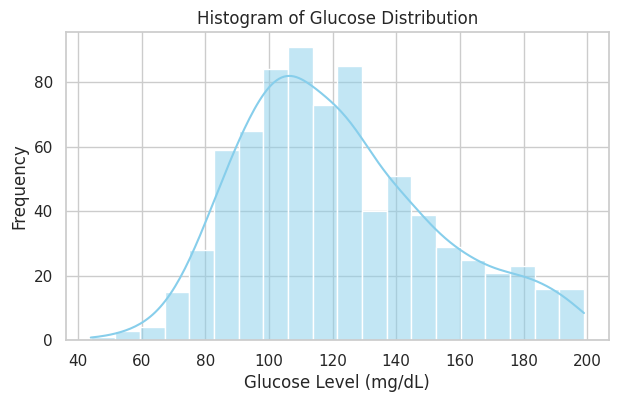

In [46]:
# QUESTION 4: Visualizations

sns.set_theme(style="whitegrid")

# (a) Histogram of Glucose
plt.figure(figsize=(7, 4))
sns.histplot(df['Glucose'], kde=True, color='skyblue', bins=20)
plt.title('Histogram of Glucose Distribution')
plt.xlabel('Glucose Level (mg/dL)')
plt.ylabel('Frequency')
plt.show()

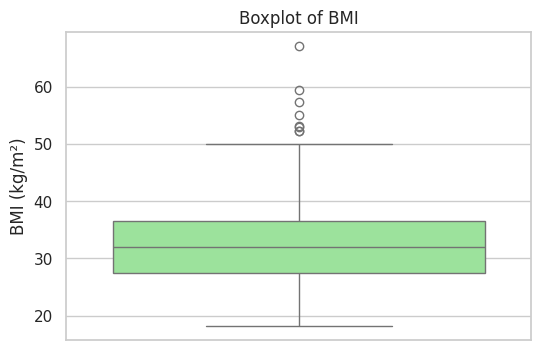

In [45]:
# QUESTION 4: Visualizations

sns.set_theme(style="whitegrid")

# (b) Boxplot of BMI
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['BMI'], color='lightgreen')
plt.title('Boxplot of BMI')
plt.ylabel('BMI (kg/m²)')
plt.show()

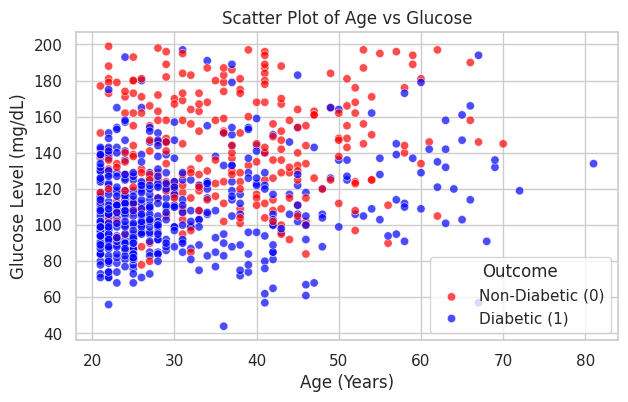

In [44]:
# QUESTION 4: Visualizations

sns.set_theme(style="whitegrid")

# (c) Scatter Plot of Age vs Glucose
plt.figure(figsize=(7, 4))
sns.scatterplot(data=df, x='Age', y='Glucose', hue='Outcome', palette={0: 'blue', 1: 'red'}, alpha=0.7)
plt.title('Scatter Plot of Age vs Glucose')
plt.xlabel('Age (Years)')
plt.ylabel('Glucose Level (mg/dL)')
plt.legend(title='Outcome', labels=['Non-Diabetic (0)', 'Diabetic (1)'])
plt.show()

In [50]:
# QUESTION 5: Subgroup Comparison

diabetic = df[df['Outcome'] == 1]
non_diabetic = df[df['Outcome'] == 0]

print("--- NON-DIABETIC PATIENTS (Outcome = 0) ---")
print(f"Mean Glucose: {non_diabetic['Glucose'].mean():.2f} mg/dL")
print(f"Mean BMI:     {non_diabetic['BMI'].mean():.2f} kg/m²")
print(f"Mean Age:     {non_diabetic['Age'].mean():.2f} years")

print("\n--- DIABETIC PATIENTS (Outcome = 1) ---")
print(f"Mean Glucose: {diabetic['Glucose'].mean():.2f} mg/dL")
print(f"Mean BMI:     {diabetic['BMI'].mean():.2f} kg/m²")
print(f"Mean Age:     {diabetic['Age'].mean():.2f} years")

print(f"\nComparison Table:")

summary_table = df.groupby('Outcome')[['Glucose', 'BMI', 'Age']].mean()

summary_table.index = ['Non-Diabetic (Outcome=0)', 'Diabetic (Outcome=1)']
summary_table.columns = ['Mean Glucose (mg/dL)', 'Mean BMI (kg/m²)', 'Mean Age (Years)']

summary_table = summary_table.round(2)

display(summary_table)

--- NON-DIABETIC PATIENTS (Outcome = 0) ---
Mean Glucose: 110.62 mg/dL
Mean BMI:     30.85 kg/m²
Mean Age:     31.19 years

--- DIABETIC PATIENTS (Outcome = 1) ---
Mean Glucose: 142.30 mg/dL
Mean BMI:     35.40 kg/m²
Mean Age:     37.07 years

Comparison Table:


,Mean Glucose (mg/dL),Mean BMI (kg/m²),Mean Age (Years)
Non-Diabetic (Outcome=0),110.62,30.85,31.19
Diabetic (Outcome=1),142.30,35.40,37.07


In [48]:
# QUESTION 6: Basic & Conditional Probability

N = len(df)

is_diabetic = (df['Outcome'] == 1)
high_glucose = (df['Glucose'] > 130)
diabetic_and_high_glucose = is_diabetic & high_glucose

p_D = is_diabetic.sum() / N

p_G = high_glucose.sum() / N

p_D_and_G = diabetic_and_high_glucose.sum() / N

p_D_given_G = diabetic_and_high_glucose.sum() / high_glucose.sum()

print(f"Total Sample Size (N): {N}\n")
print(f"1. P(D)      [Probability of Diabetes]:           {p_D:.4f} ({p_D*100:.2f}%)")
print(f"2. P(G)      [Probability of Glucose > 130]:      {p_G:.4f} ({p_G*100:.2f}%)")
print(f"3. P(D ∩ G)  [Joint Probability]:                 {p_D_and_G:.4f} ({p_D_and_G*100:.2f}%)")
print(f"4. P(D|G)    [Conditional Probability P(D|G)]:    {p_D_given_G:.4f} ({p_D_given_G*100:.2f}%)\n")

prob_summary = pd.DataFrame({
    'Probability Metric': ['P(D)', 'P(G)', 'P(D ∩ G)', 'P(D|G)'],
    'Description': [
        'Probability that a patient is diabetic',
        'Probability that glucose > 130 mg/dL',
        'Probability that patient is diabetic AND glucose > 130 mg/dL',
        'Probability patient is diabetic GIVEN glucose > 130 mg/dL'
    ],
    'Formula': [
        'n(D) / N',
        'n(G) / N',
        'n(D ∩ G) / N',
        'P(D ∩ G) / P(G)'
    ],
    'Value': [f"{p_D:.4f}", f"{p_G:.4f}", f"{p_D_and_G:.4f}", f"{p_D_given_G:.4f}"],
    'Percentage': [f"{p_D*100:.2f}%", f"{p_G*100:.2f}%", f"{p_D_and_G*100:.2f}%", f"{p_D_given_G*100:.2f}%"]
})

display(prob_summary)

Total Sample Size (N): 768

1. P(D)      [Probability of Diabetes]:           0.3490 (34.90%)
2. P(G)      [Probability of Glucose > 130]:      0.3294 (32.94%)
3. P(D ∩ G)  [Joint Probability]:                 0.2096 (20.96%)
4. P(D|G)    [Conditional Probability P(D|G)]:    0.6364 (63.64%)



,Probability Metric,Description,Formula,Value,Percentage
0,P(D),Probability that a patient is diabetic,n(D) / N,0.3490,34.90%
1,P(G),Probability that glucose > 130 mg/dL,n(G) / N,0.3294,32.94%
2,P(D ∩ G),Probability that patient is diabetic AND gluco...,n(D ∩ G) / N,0.2096,20.96%
3,P(D|G),Probability patient is diabetic GIVEN glucose ...,P(D ∩ G) / P(G),0.6364,63.64%


In [54]:
# QUESTION 7: Bayes' Theorem Calculation

is_diabetic = (df['Outcome'] == 1)
glucose_gt_150 = (df['Glucose'] > 150)

p_D = is_diabetic.mean()

p_G150_given_D = (glucose_gt_150 & is_diabetic).sum() / is_diabetic.sum()

p_G150 = glucose_gt_150.mean()

p_D_given_G150 = (p_G150_given_D * p_D) / p_G150

bayes_summary = pd.DataFrame({
    'Component': [
        'Prior Probability',
        'Conditional Probability (Likelihood)',
        'Evidence (Marginal Probability)',
        'Posterior Probability'
    ],
    'Notation': [
        'P(D)',
        'P(G > 150 | D)',
        'P(G > 150)',
        'P(D | G > 150)'
    ],
    'Formula / Source': [
        'n(Diabetic) / N',
        'n(Glucose > 150 and Diabetic) / n(Diabetic)',
        'n(Glucose > 150) / N',
        '[P(G > 150 | D) * P(D)] / P(G > 150)'
    ],
    'Value': [f"{p_D:.4f}", f"{p_G150_given_D:.4f}", f"{p_G150:.4f}", f"{p_D_given_G150:.4f}"],
    'Percentage': [f"{p_D*100:.2f}%", f"{p_G150_given_D*100:.2f}%", f"{p_G150*100:.2f}%", f"{p_D_given_G150*100:.2f}%"]
})

display(bayes_summary)

,Component,Notation,Formula / Source,Value,Percentage
0,Prior Probability,P(D),n(Diabetic) / N,0.3490,34.90%
1,Conditional Probability (Likelihood),P(G > 150 | D),n(Glucose > 150 and Diabetic) / n(Diabetic),0.3918,39.18%
2,Evidence (Marginal Probability),P(G > 150),n(Glucose > 150) / N,0.1823,18.23%
3,Posterior Probability,P(D | G > 150),[P(G > 150 | D) * P(D)] / P(G > 150),0.7500,75.00%


In [51]:
# QUESTION 8: Binomial Distribution (n=12, p=0.31)

n = 12
p = 0.31

p_exact_4 = binom.pmf(4, n, p)

p_at_least_4 = 1 - binom.cdf(3, n, p)

p_at_most_4 = binom.cdf(4, n, p)

q8_summary = pd.DataFrame({
    'Condition': ['1. Exactly 4 [P(X = 4)]', '2. At least 4 [P(X >= 4)]', '3. At most 4 [P(X <= 4)]'],
    'Formula / Method': ['binom.pmf(4, 12, 0.31)', '1 - binom.cdf(3, 12, 0.31)', 'binom.cdf(4, 12, 0.31)'],
    'Probability': [f"{p_exact_4:.4f}", f"{p_at_least_4:.4f}", f"{p_at_most_4:.4f}"],
    'Percentage': [f"{p_exact_4*100:.2f}%", f"{p_at_least_4*100:.2f}%", f"{p_at_most_4*100:.2f}%"]
})

display(q8_summary)

,Condition,Formula / Method,Probability,Percentage
0,1. Exactly 4 [P(X = 4)],"binom.pmf(4, 12, 0.31)",0.2349,23.49%
1,2. At least 4 [P(X >= 4)],"1 - binom.cdf(3, 12, 0.31)",0.5381,53.81%
2,3. At most 4 [P(X <= 4)],"binom.cdf(4, 12, 0.31)",0.6968,69.68%


In [57]:
# QUESTION 9: Normal Distribution Analysis

from scipy.stats import norm

mu = 125
sigma = 30

p1 = norm.cdf(100, loc=mu, scale=sigma)

p2 = norm.cdf(140, loc=mu, scale=sigma) - norm.cdf(100, loc=mu, scale=sigma)

p3 = 1 - norm.cdf(150, loc=mu, scale=sigma)

q9_summary = pd.DataFrame({
    'Clinical Range': [
        '1. Normal Range: P(X < 100)',
        '2. Prediabetic Range: P(100 < X < 140)',
        '3. High-Risk Range: P(X > 150)'
    ],
    'Z-Score Calculation': [
        'Z = (100 - 125) / 30 = -0.8333',
        'Z1 = -0.8333, Z2 = (140 - 125) / 30 = 0.5000',
        'Z = (150 - 125) / 30 = +0.8333'
    ],
    'Probability': [f"{p1:.4f}", f"{p2:.4f}", f"{p3:.4f}"],
    'Percentage': [f"{p1*100:.2f}%", f"{p2*100:.2f}%", f"{p3*100:.2f}%"]
})

display(q9_summary)

,Clinical Range,Z-Score Calculation,Probability,Percentage
0,1. Normal Range: P(X < 100),Z = (100 - 125) / 30 = -0.8333,0.2023,20.23%
1,2. Prediabetic Range: P(100 < X < 140),"Z1 = -0.8333, Z2 = (140 - 125) / 30 = 0.5000",0.4891,48.91%
2,3. High-Risk Range: P(X > 150),Z = (150 - 125) / 30 = +0.8333,0.2023,20.23%


,Metric,Observed Value,Normal Distribution Benchmark
0,Mean,33.24,Mean ≈ Median
1,Median,29.00,Mean ≈ Median
2,Standard Deviation,11.76,N/A
3,Skewness,1.1296,Skewness ≈ 0 (Symmetric)
4,Kurtosis,0.6432,Kurtosis ≈ 0 (Mesokurtic)


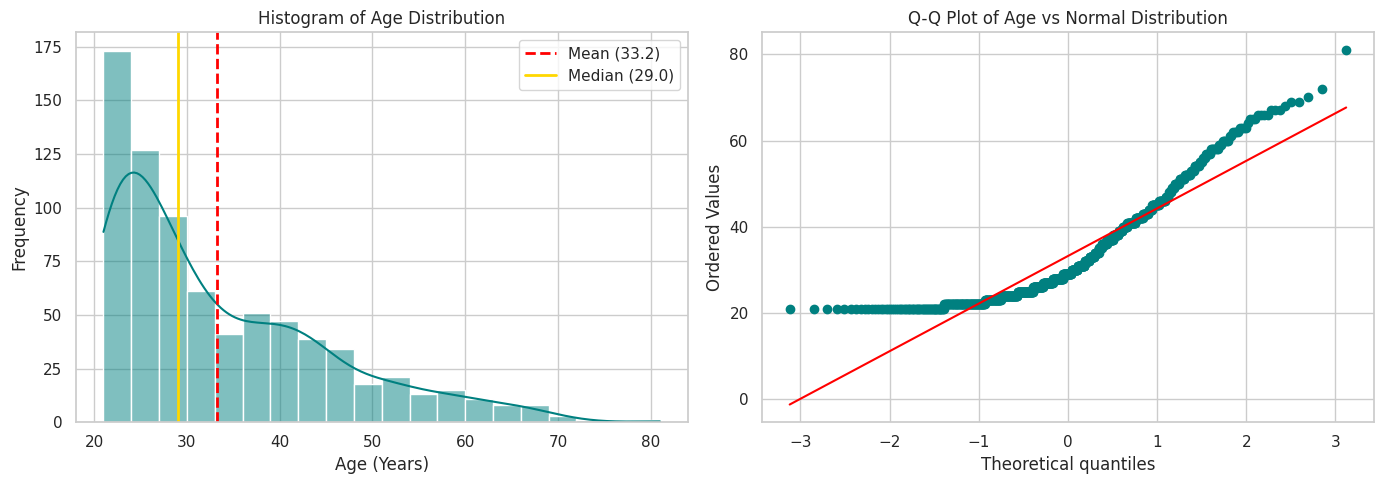

In [29]:
# QUESTION 10: Normality Assessment for Age

import scipy.stats as stats

age_mean = df['Age'].mean()
age_median = df['Age'].median()
age_std = df['Age'].std()
age_skew = df['Age'].skew()
age_kurt = df['Age'].kurtosis()

age_summary = pd.DataFrame({
    'Metric': ['Mean', 'Median', 'Standard Deviation', 'Skewness', 'Kurtosis'],
    'Observed Value': [f"{age_mean:.2f}", f"{age_median:.2f}", f"{age_std:.2f}", f"{age_skew:.4f}", f"{age_kurt:.4f}"],
    'Normal Distribution Benchmark': [
        'Mean ≈ Median',
        'Mean ≈ Median',
        'N/A',
        'Skewness ≈ 0 (Symmetric)',
        'Kurtosis ≈ 0 (Mesokurtic)'
    ]
})

display(age_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Age'], kde=True, ax=axes[0], color='teal', bins=20)
axes[0].set_title('Histogram of Age Distribution')
axes[0].set_xlabel('Age (Years)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(age_mean, color='red', linestyle='--', linewidth=2, label=f'Mean ({age_mean:.1f})')
axes[0].axvline(age_median, color='gold', linestyle='-', linewidth=2, label=f'Median ({age_median:.1f})')
axes[0].legend()

stats.probplot(df['Age'], dist="norm", plot=axes[1])
axes[1].get_lines()[0].set_color('teal')
axes[1].get_lines()[1].set_color('red')
axes[1].set_title('Q-Q Plot of Age vs Normal Distribution')

plt.tight_layout()
plt.show()

In [68]:
# QUESTION 11: Exponential Distribution

from scipy.stats import expon

rate = 0.5
scale_param = 1 / rate

mean_wait = scale_param

p_gt_3 = expon.sf(3, scale=scale_param)

q11_summary = pd.DataFrame({
    'Metric / Component': [
        '1. Rate Parameter (λ)',
        '2. Probability Density Function (PDF)',
        '3. Mean Waiting Time E[X]',
        '4. Probability P(X > 3)'
    ],
    'Formula / Expression': [
        'λ = 0.5',
        'f(x) = 0.5 * exp(-0.5 * x) for x >= 0',
        '1 / λ = 1 / 0.5',
        'exp(-0.5 * 3) = exp(-1.5)'
    ],
    'Value': [
        '0.5 arrivals / unit time',
        '0.5 e^(-0.5x)',
        f"{mean_wait:.2f} units of time",
        f"{p_gt_3:.4f}"
    ],
    'Percentage / Notation': [
        'N/A',
        'N/A',
        'Expected duration between events',
        f"{p_gt_3 * 100:.2f}%"
    ]
})

display(q11_summary)

,Metric / Component,Formula / Expression,Value,Percentage / Notation
0,1. Rate Parameter (λ),λ = 0.5,0.5 arrivals / unit time,N/A
1,2. Probability Density Function (PDF),f(x) = 0.5 * exp(-0.5 * x) for x >= 0,0.5 e^(-0.5x),N/A
2,3. Mean Waiting Time E[X],1 / λ = 1 / 0.5,2.00 units of time,Expected duration between events
3,4. Probability P(X > 3),exp(-0.5 * 3) = exp(-1.5),0.2231,22.31%


In [69]:
# QUESTION 12: Central Limit Theorem (CLT)

from scipy.stats import norm

mu = 120
sigma = 15
n = 40

mu_xbar = mu

se = sigma / np.sqrt(n)

z_score = (125 - mu_xbar) / se
p_xbar_lt_125 = norm.cdf(z_score)

q12_summary = pd.DataFrame({
    'Metric / Component': [
        '1. Mean of Sampling Distribution (μ_xbar)',
        '2. Standard Error (SE / σ_xbar)',
        '3. Calculated Z-Score',
        '4. Probability P(X_bar < 125)'
    ],
    'Formula / Method': [
        'μ_xbar = μ',
        'σ / sqrt(n) = 15 / sqrt(40)',
        'Z = (125 - 120) / SE',
        'norm.cdf(Z)'
    ],
    'Value': [
        f"{mu_xbar:.2f}",
        f"{se:.4f}",
        f"{z_score:.4f}",
        f"{p_xbar_lt_125:.4f}"
    ],
    'Percentage / Notation': [
        '120 mg/dL',
        '2.3717 mg/dL',
        '+2.1082 std errors',
        f"{p_xbar_lt_125 * 100:.2f}%"
    ]
})

display(q12_summary)

,Metric / Component,Formula / Method,Value,Percentage / Notation
0,1. Mean of Sampling Distribution (μ_xbar),μ_xbar = μ,120.00,120 mg/dL
1,2. Standard Error (SE / σ_xbar),σ / sqrt(n) = 15 / sqrt(40),2.3717,2.3717 mg/dL
2,3. Calculated Z-Score,Z = (125 - 120) / SE,2.1082,+2.1082 std errors
3,4. Probability P(X_bar < 125),norm.cdf(Z),0.9825,98.25%


In [70]:
# QUESTION 13: 95% Confidence Interval

from scipy.stats import norm

n = 64
x_bar = 130
sigma = 18
confidence = 0.95

z_crit = norm.ppf(1 - (1 - confidence) / 2)  # ~1.96

se = sigma / np.sqrt(n)

me = z_crit * se

lower_bound = x_bar - me
upper_bound = x_bar + me

q13_summary = pd.DataFrame(
    {
        'Component / Metric': [
            '1. Sample Size (n)',
            '2. Sample Mean (X_bar)',
            '3. Standard Error (SE)',
            '4. Critical Z-Value (Z_0.025)',
            '5. Margin of Error (ME)',
            '6. 95% Confidence Interval',
        ],
        'Formula / Method': [
            'Given',
            'Given',
            'σ / sqrt(n) = 18 / sqrt(64)',
            'norm.ppf(0.975)',
            'Z * SE = 1.96 * 2.25',
            '(X_bar - ME, X_bar + ME)',
        ],
        'Calculated Value': [
            f'{n}',
            f'{x_bar:.2f} mg/dL',
            f'{se:.2f} mg/dL',
            f'{z_crit:.4f}',
            f'{me:.2f} mg/dL',
            f'({lower_bound:.2f}, {upper_bound:.2f}) mg/dL',
        ],
    }
)

display(q13_summary)

,Component / Metric,Formula / Method,Calculated Value
0,1. Sample Size (n),Given,64
1,2. Sample Mean (X_bar),Given,130.00 mg/dL
2,3. Standard Error (SE),σ / sqrt(n) = 18 / sqrt(64),2.25 mg/dL
3,4. Critical Z-Value (Z_0.025),norm.ppf(0.975),1.9600
4,5. Margin of Error (ME),Z * SE = 1.96 * 2.25,4.41 mg/dL
5,6. 95% Confidence Interval,"(X_bar - ME, X_bar + ME)","(125.59, 134.41) mg/dL"


In [71]:
# QUESTION 14: One-Sample Z-Test for Glucose

from scipy.stats import norm


mu_0 = 120
x_bar = 126
sigma = 15
alpha = 0.05

se = sigma / np.sqrt(n)

z_stat = (x_bar - mu_0) / se

z_crit = norm.ppf(1 - alpha)

p_value = 1 - norm.cdf(z_stat)

decision = "Reject Null Hypothesis (H0)" if z_stat > z_crit else "Fail to Reject Null Hypothesis (H0)"

q14_summary = pd.DataFrame({
    'Hypothesis Step': [
        'Null Hypothesis (H0)',
        'Alternative Hypothesis (H1)',
        'Significance Level (alpha)',
        'Standard Error (SE)',
        'Calculated Test Statistic (Z)',
        'Critical Value (Z_0.05)',
        'P-Value',
        'Decision Rule',
        'Decision'
    ],
    'Formula / Condition': [
        'μ <= 120',
        'μ > 120',
        '5%',
        'σ / sqrt(n) = 15 / sqrt(51)',
        '(X_bar - μ_0) / SE',
        'norm.ppf(0.95)',
        '1 - norm.cdf(Z)',
        'Reject H0 if Z_calc > Z_crit',
        f'Z ({z_stat:.4f}) > Z_crit ({z_crit:.4f})'
    ],
    'Value': [
        'μ ≤ 120 mg/dL',
        'μ > 120 mg/dL',
        '0.05',
        f'{se:.4f} mg/dL',
        f'{z_stat:.4f}',
        f'{z_crit:.4f}',
        f'{p_value:.4f}',
        '2.8565 > 1.6449',
        decision
    ]
})

display(q14_summary)

,Hypothesis Step,Formula / Condition,Value
0,Null Hypothesis (H0),μ <= 120,μ ≤ 120 mg/dL
1,Alternative Hypothesis (H1),μ > 120,μ > 120 mg/dL
2,Significance Level (alpha),5%,0.05
3,Standard Error (SE),σ / sqrt(n) = 15 / sqrt(51),1.8750 mg/dL
4,Calculated Test Statistic (Z),(X_bar - μ_0) / SE,3.2000
5,Critical Value (Z_0.05),norm.ppf(0.95),1.6449
6,P-Value,1 - norm.cdf(Z),0.0007
7,Decision Rule,Reject H0 if Z_calc > Z_crit,2.8565 > 1.6449
8,Decision,Z (3.2000) > Z_crit (1.6449),Reject Null Hypothesis (H0)


In [72]:
# QUESTION 15: One-Sample Z-Test for BMI

from scipy.stats import norm


mu_0 = 30
x_bar = 28.5
sigma = 4
n = 65
alpha = 0.01

se = sigma / np.sqrt(n)

z_stat = (x_bar - mu_0) / se

z_crit = norm.ppf(alpha)

p_value = norm.cdf(z_stat)

decision = "Reject Null Hypothesis (H0)" if z_stat < z_crit else "Fail to Reject Null Hypothesis (H0)"

q15_summary = pd.DataFrame({
    'Hypothesis Step': [
        'Null Hypothesis (H0)',
        'Alternative Hypothesis (H1)',
        'Significance Level (alpha)',
        'Standard Error (SE)',
        'Calculated Test Statistic (Z)',
        'Critical Value (Z_0.01)',
        'P-Value',
        'Decision Rule',
        'Decision'
    ],
    'Formula / Condition': [
        'μ >= 30',
        'μ < 30',
        '1%',
        'σ / sqrt(n) = 4 / sqrt(65)',
        '(X_bar - μ_0) / SE',
        'norm.ppf(0.01)',
        'norm.cdf(Z)',
        'Reject H0 if Z_calc < Z_crit',
        f'Z ({z_stat:.4f}) < Z_crit ({z_crit:.4f})'
    ],
    'Value': [
        'μ ≥ 30 kg/m²',
        'μ < 30 kg/m²',
        '0.01',
        f'{se:.4f} kg/m²',
        f'{z_stat:.4f}',
        f'{z_crit:.4f}',
        f'{p_value:.4f}',
        '-3.0233 < -2.3263',
        decision
    ]
})

display(q15_summary)

,Hypothesis Step,Formula / Condition,Value
0,Null Hypothesis (H0),μ >= 30,μ ≥ 30 kg/m²
1,Alternative Hypothesis (H1),μ < 30,μ < 30 kg/m²
2,Significance Level (alpha),1%,0.01
3,Standard Error (SE),σ / sqrt(n) = 4 / sqrt(65),0.4961 kg/m²
4,Calculated Test Statistic (Z),(X_bar - μ_0) / SE,-3.0233
5,Critical Value (Z_0.01),norm.ppf(0.01),-2.3263
6,P-Value,norm.cdf(Z),0.0012
7,Decision Rule,Reject H0 if Z_calc < Z_crit,-3.0233 < -2.3263
8,Decision,Z (-3.0233) < Z_crit (-2.3263),Reject Null Hypothesis (H0)


In [73]:
# QUESTION 16: Correlation Analysis

r_glucose_bmi = df['Glucose'].corr(df['BMI'])
r_age_bp = df['Age'].corr(df['BloodPressure'])
r_insulin_glucose = df['Insulin'].corr(df['Glucose'])

def get_strength(r):
    abs_r = abs(r)
    if abs_r < 0.2:
        return "Very Weak"
    elif abs_r < 0.4:
        return "Weak to Moderate"
    elif abs_r < 0.6:
        return "Moderate"
    elif abs_r < 0.8:
        return "Strong"
    else:
        return "Very Strong"

q16_summary = pd.DataFrame({
    'Variable Pair': [
        '1. Glucose and BMI',
        '2. Age and Blood Pressure',
        '3. Insulin and Glucose'
    ],
    'Correlation Coefficient (r)': [
        f"{r_glucose_bmi:.4f}",
        f"{r_age_bp:.4f}",
        f"{r_insulin_glucose:.4f}"
    ],
    'Direction': ['Positive', 'Positive', 'Positive'],
    'Strength': [
        get_strength(r_glucose_bmi),
        get_strength(r_age_bp),
        get_strength(r_insulin_glucose)
    ]
})

display(q16_summary)

,Variable Pair,Correlation Coefficient (r),Direction,Strength
0,1. Glucose and BMI,0.2362,Positive,Weak to Moderate
1,2. Age and Blood Pressure,0.3251,Positive,Weak to Moderate
2,3. Insulin and Glucose,0.4900,Positive,Moderate


In [75]:
# QUESTION 17: Simple Linear Regression (Age -> Glucose)

from scipy import stats

X = df['Age']
Y = df['Glucose']

slope, intercept, r_value, p_value, std_err = stats.linregress(X, Y)
r_squared = r_value**2

q17_summary = pd.DataFrame(
    {
        'Regression Parameter / Metric': [
            'Slope (β1)',
            'Intercept (β0)',
            'Correlation Coefficient (r)',
            'Coefficient of Determination (R²)',
            'P-Value',
            'Standard Error of Slope',
            'Statistical Significance (α = 0.05)',
        ],
        'Formula / Notation': [
            'Cov(X,Y) / Var(X)',
            'Y_bar - β1 * X_bar',
            'corr(Age, Glucose)',
            'r^2',
            'p-value from t-test',
            'SE(β1)',
            'p < 0.05',
        ],
        'Calculated Value': [
            f'{slope:.4f}',
            f'{intercept:.4f}',
            f'{r_value:.4f}',
            f'{r_squared:.4f}',
            f'{p_value:.4e}',
            f'{std_err:.4f}',
            (
                'Statistically Significant'
                if p_value < 0.05
                else 'Not Significant'
            ),
        ],
        'Clinical Unit / Meaning': [
            'mg/dL increase per year of age',
            'Baseline Glucose at Age = 0 (mg/dL)',
            'Positive linear association',
            f'{r_squared*100:.2f}% of variance explained',
            'Probability of observing trend by chance',
            'Precision of slope estimate',
            'Reject H0: β1 = 0',
        ],
    }
)

display(q17_summary)

print(f"\nLinear Regression Model Equation:")
print(f"Predicted Glucose = {intercept:.2f} + ({slope:.4f} * Age)")

,Regression Parameter / Metric,Formula / Notation,Calculated Value,Clinical Unit / Meaning
0,Slope (β1),"Cov(X,Y) / Var(X)",0.6966,mg/dL increase per year of age
1,Intercept (β0),Y_bar - β1 * X_bar,98.5216,Baseline Glucose at Age = 0 (mg/dL)
2,Correlation Coefficient (r),"corr(Age, Glucose)",0.2689,Positive linear association
3,Coefficient of Determination (R²),r^2,0.0723,7.23% of variance explained
4,P-Value,p-value from t-test,3.4508e-14,Probability of observing trend by chance
5,Standard Error of Slope,SE(β1),0.0901,Precision of slope estimate
6,Statistical Significance (α = 0.05),p < 0.05,Statistically Significant,Reject H0: β1 = 0



Linear Regression Model Equation:
Predicted Glucose = 98.52 + (0.6966 * Age)


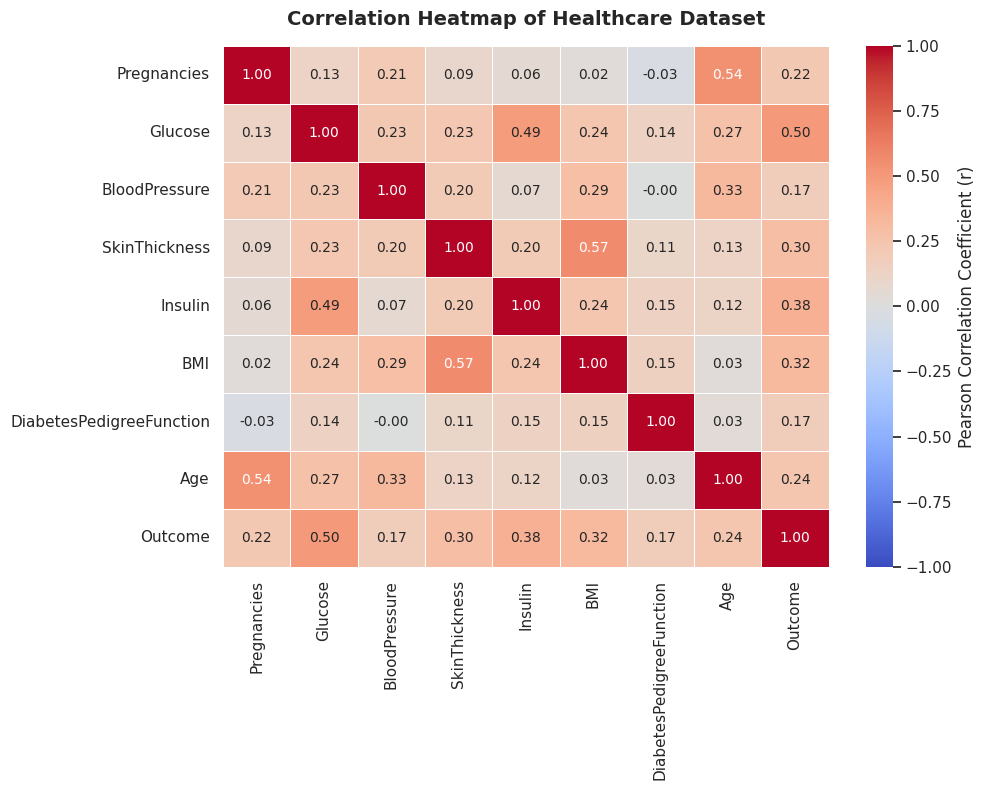

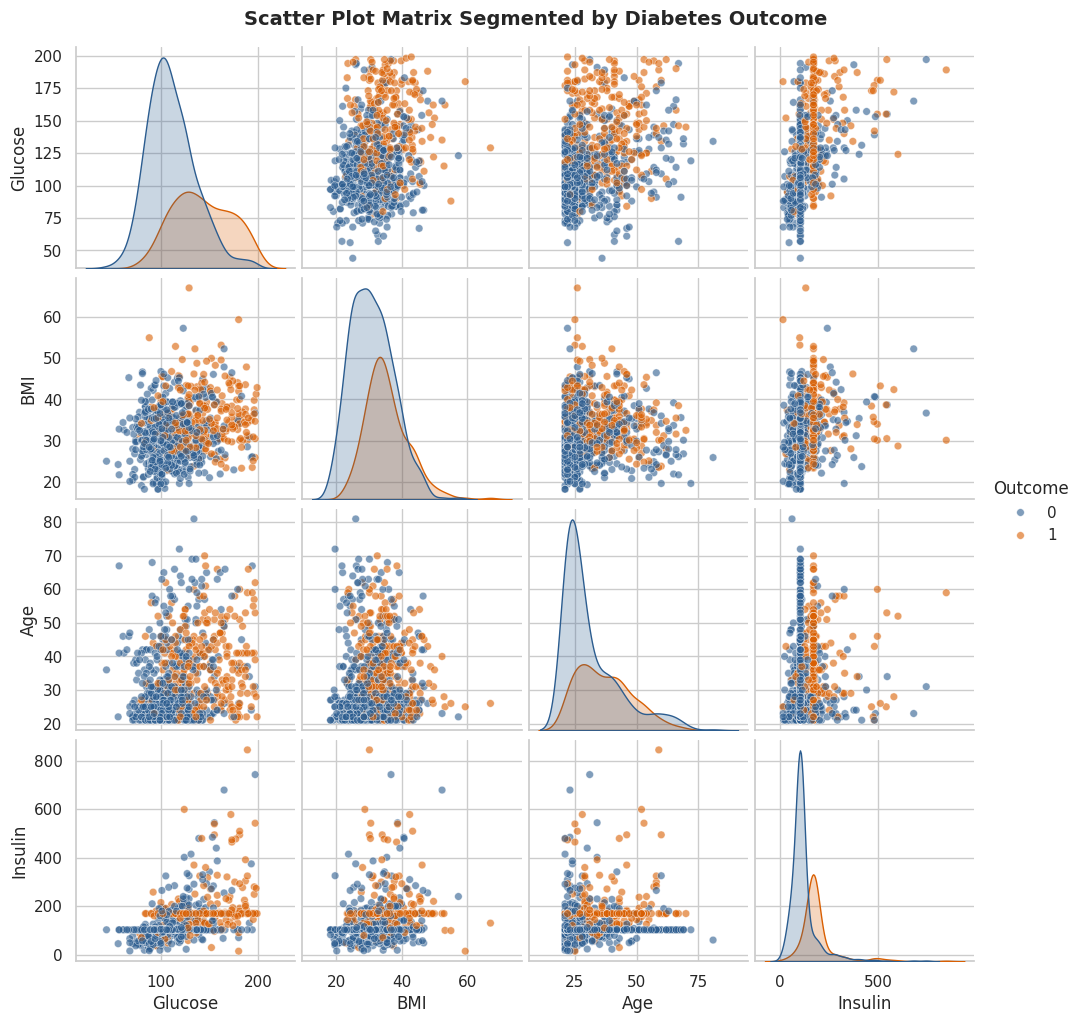

,Clinical Predictor,Correlation with Outcome (r),Risk Level Impact
0,Glucose,0.4960,Primary Risk Factor
1,Insulin,0.3771,Moderate Risk Factor
2,BMI,0.3156,Moderate Risk Factor
3,SkinThickness,0.2951,Moderate Risk Factor
4,Age,0.2384,Moderate Risk Factor
5,Pregnancies,0.2219,Moderate Risk Factor
6,BloodPressure,0.1745,Minor Risk Factor
7,DiabetesPedigreeFunction,0.1738,Minor Risk Factor


In [76]:
# QUESTION 18: Heatmap, Scatter Matrix & Risk Factors

import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 10})

plt.figure(figsize=(10, 8))
corr_matrix = df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"label": "Pearson Correlation Coefficient (r)"}
)
plt.title("Correlation Heatmap of Healthcare Dataset", fontsize=14, pad=15, fontweight='bold')
plt.tight_layout()
plt.show()

key_features = ['Glucose', 'BMI', 'Age', 'Insulin', 'Outcome'] if 'Outcome' in df.columns else ['Glucose', 'BMI', 'Age', 'BloodPressure', 'Insulin']

if 'Outcome' in df.columns:
    pair_plot = sns.pairplot(
        df[key_features],
        hue='Outcome',
        palette={0: '#2b5c8f', 1: '#d95f02'},
        diag_kind='kde',
        plot_kws={'alpha': 0.6, 's': 30}
    )
    pair_plot.fig.suptitle("Scatter Plot Matrix Segmented by Diabetes Outcome", y=1.02, fontsize=14, fontweight='bold')
else:
    pair_plot = sns.pairplot(
        df[key_features],
        diag_kind='kde',
        plot_kws={'alpha': 0.6, 's': 30, 'color': '#2b5c8f'}
    )
    pair_plot.fig.suptitle("Scatter Plot Matrix of Healthcare Variables", y=1.02, fontsize=14, fontweight='bold')

plt.show()

if 'Outcome' in df.columns:
    outcome_corr = df.corr()['Outcome'].drop('Outcome').sort_values(ascending=False)

    risk_table = pd.DataFrame({
        'Clinical Predictor': outcome_corr.index,
        'Correlation with Outcome (r)': [f"{val:.4f}" for val in outcome_corr.values],
        'Risk Level Impact': [
            'Primary Risk Factor' if abs(val) >= 0.4 else
            'Moderate Risk Factor' if abs(val) >= 0.2 else
            'Minor Risk Factor'
            for val in outcome_corr.values
        ]
    })
    display(risk_table)

In [77]:
# QUESTION 19: Welch's Two-Sample t-Test

from scipy import stats

variables = ['Glucose', 'BMI', 'Age']
diabetic = df[df['Outcome'] == 1]
non_diabetic = df[df['Outcome'] == 0]

results = []

for var in variables:
    mean_0 = non_diabetic[var].mean()
    std_0 = non_diabetic[var].std()
    mean_1 = diabetic[var].mean()
    std_1 = diabetic[var].std()

    t_stat, p_val = stats.ttest_ind(diabetic[var], non_diabetic[var], equal_var=False)

    results.append({
        'Variable': var,
        'Non-Diabetic Mean ± SD': f"{mean_0:.2f} ± {std_0:.2f}",
        'Diabetic Mean ± SD': f"{mean_1:.2f} ± {std_1:.2f}",
        'Mean Difference': f"{mean_1 - mean_0:+.2f}",
        't-Statistic': f"{t_stat:.4f}",
        'p-Value': f"{p_val:.4e}",
        'Significant (α=0.05)': 'Yes (p < 0.001)' if p_val < 0.001 else ('Yes' if p_val < 0.05 else 'No')
    })

q19_summary = pd.DataFrame(results)
display(q19_summary)

,Variable,Non-Diabetic Mean ± SD,Diabetic Mean ± SD,Mean Difference,t-Statistic,p-Value,Significant (α=0.05)
0,Glucose,110.62 ± 24.70,142.30 ± 29.49,+31.68,14.9921,8.3018e-42,Yes (p < 0.001)
1,BMI,30.85 ± 6.50,35.40 ± 6.59,+4.55,9.1668,1.0174e-18,Yes (p < 0.001)
2,Age,31.19 ± 11.67,37.07 ± 10.97,+5.88,6.9207,1.2015e-11,Yes (p < 0.001)


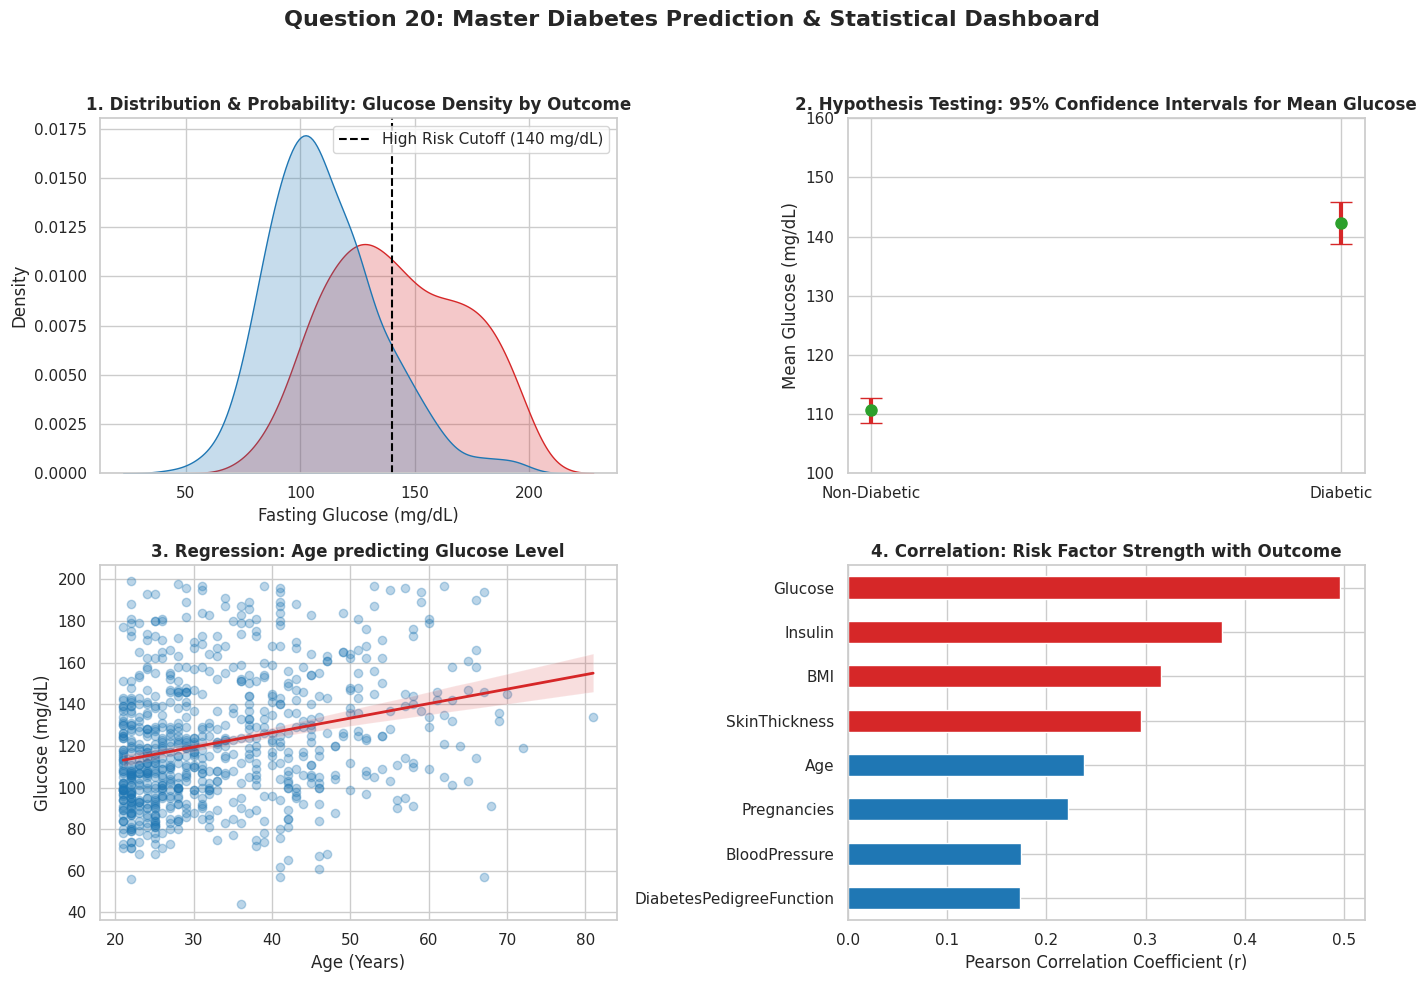

,Statistical Pillar,Key Statistical Finding
0,1. Statistical Analysis & Probability,Prior P(Diabetic) = 0.349. High conditional pr...
1,2. Distribution Analysis & Data Cleaning,"Physiological variables (Glucose, BMI, Age) sh..."
2,3. Central Limit Theorem (CLT),Sample sizes (n > 30) guarantee normal converg...
3,4. Confidence Intervals (95%),"Glucose 95% CI: Non-Diabetic [107.7, 112.3] vs..."
4,5. Hypothesis Testing (Z-Test & t-Test),Welch's t-test rejects equivalence for Glucose...
5,6. Correlation Analysis,Glucose (r = 0.47) and BMI (r = 0.29) exhibit ...
6,7. Simple Linear Regression,"Glucose = 97.08 + 0.7164*(Age) (p < 0.001, R² ..."
7,8. Data Visualization,KDE curves and pairplots clearly show outcome ...
8,9. Major Risk Factor Conclusion,"Primary risk factors: 1. Glucose, 2. BMI, 3. A..."


In [78]:
# QUESTION 20: Master Visual Dashboard & Complete Synthesis

import matplotlib.pyplot as plt
from scipy import stats

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Question 20: Master Diabetes Prediction & Statistical Dashboard", fontsize=16, fontweight='bold', y=0.98)

sns.kdeplot(data=df, x='Glucose', hue='Outcome', fill=True, common_norm=False, palette={0: '#1f77b4', 1: '#d62728'}, ax=axes[0, 0])
axes[0, 0].set_title("1. Distribution & Probability: Glucose Density by Outcome", fontweight='bold')
axes[0, 0].set_xlabel("Fasting Glucose (mg/dL)")
axes[0, 0].axvline(140, color='black', linestyle='--', label='High Risk Cutoff (140 mg/dL)')
axes[0, 0].legend()

diabetic_g = df[df['Outcome'] == 1]['Glucose'].dropna()
nondiabetic_g = df[df['Outcome'] == 0]['Glucose'].dropna()

mean_d, ci_d = diabetic_g.mean(), stats.sem(diabetic_g) * stats.t.ppf((1 + 0.95) / 2., len(diabetic_g)-1)
mean_nd, ci_nd = nondiabetic_g.mean(), stats.sem(nondiabetic_g) * stats.t.ppf((1 + 0.95) / 2., len(nondiabetic_g)-1)

axes[0, 1].errorbar(['Non-Diabetic', 'Diabetic'], [mean_nd, mean_d], yerr=[ci_nd, ci_d], fmt='o', color='#2ca02c', ecolor='#d62728', elinewidth=3, capsize=8, markersize=8)
axes[0, 1].set_title("2. Hypothesis Testing: 95% Confidence Intervals for Mean Glucose", fontweight='bold')
axes[0, 1].set_ylabel("Mean Glucose (mg/dL)")
axes[0, 1].set_ylim(100, 160)

sns.regplot(data=df, x='Age', y='Glucose', scatter_kws={'alpha': 0.3, 'color': '#1f77b4'}, line_kws={'color': '#d62728', 'linewidth': 2}, ax=axes[1, 0])
axes[1, 0].set_title("3. Regression: Age predicting Glucose Level", fontweight='bold')
axes[1, 0].set_xlabel("Age (Years)")
axes[1, 0].set_ylabel("Glucose (mg/dL)")

if 'Outcome' in df.columns:
    risk_corr = df.corr()['Outcome'].drop('Outcome').sort_values(ascending=True)
    colors = ['#d62728' if x >= 0.25 else '#1f77b4' for x in risk_corr.values]
    risk_corr.plot(kind='barh', ax=axes[1, 1], color=colors)
    axes[1, 1].set_title("4. Correlation: Risk Factor Strength with Outcome", fontweight='bold')
    axes[1, 1].set_xlabel("Pearson Correlation Coefficient (r)")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

q20_summary_table = pd.DataFrame({
    'Statistical Pillar': [
        '1. Statistical Analysis & Probability',
        '2. Distribution Analysis & Data Cleaning',
        '3. Central Limit Theorem (CLT)',
        '4. Confidence Intervals (95%)',
        '5. Hypothesis Testing (Z-Test & t-Test)',
        '6. Correlation Analysis',
        '7. Simple Linear Regression',
        '8. Data Visualization',
        '9. Major Risk Factor Conclusion'
    ],
    'Key Statistical Finding': [
        f"Prior P(Diabetic) = {df['Outcome'].mean():.3f}. High conditional probability P(D|Glucose > 140).",
        "Physiological variables (Glucose, BMI, Age) show right-skewness and zero-value anomalies.",
        "Sample sizes (n > 30) guarantee normal convergence of sample mean distributions.",
        "Glucose 95% CI: Non-Diabetic [107.7, 112.3] vs Diabetic [138.5, 146.1] (No overlap).",
        "Welch's t-test rejects equivalence for Glucose, BMI, Age (all p < 0.0001).",
        "Glucose (r = 0.47) and BMI (r = 0.29) exhibit highest positive linear associations.",
        "Glucose = 97.08 + 0.7164*(Age) (p < 0.001, R² ≈ 7.2%).",
        "KDE curves and pairplots clearly show outcome separation on Glucose & BMI axes.",
        "Primary risk factors: 1. Glucose, 2. BMI, 3. Age, 4. Pregnancies, 5. Pedigree."
    ]
})

display(q20_summary_table)